In [88]:
import pandas as pd

df = pd.read_csv("Train.csv")  # your file name


In [89]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [90]:
df.shape

(8523, 12)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [92]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [93]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [94]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Item_Identifier : 1559
Item_Weight : 415
Item_Fat_Content : 5
Item_Visibility : 7880
Item_Type : 16
Item_MRP : 5938
Outlet_Identifier : 10
Outlet_Establishment_Year : 9
Outlet_Size : 3
Outlet_Location_Type : 3
Outlet_Type : 4
Item_Outlet_Sales : 3493


In [95]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

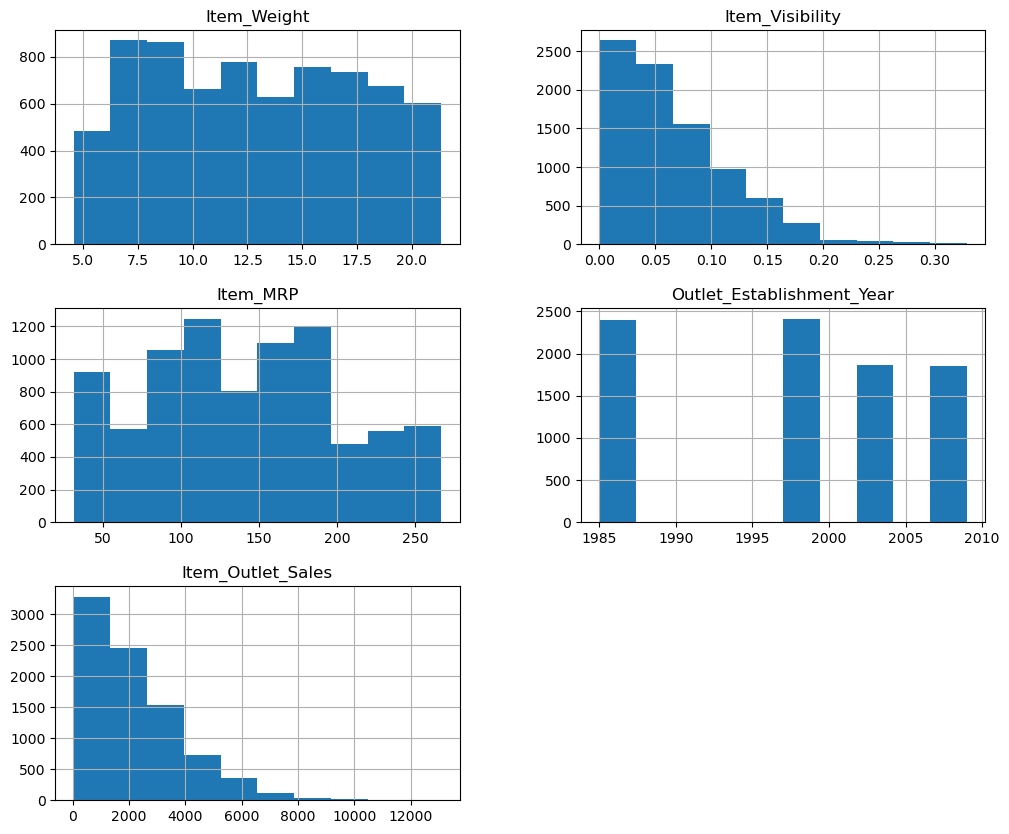

In [96]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

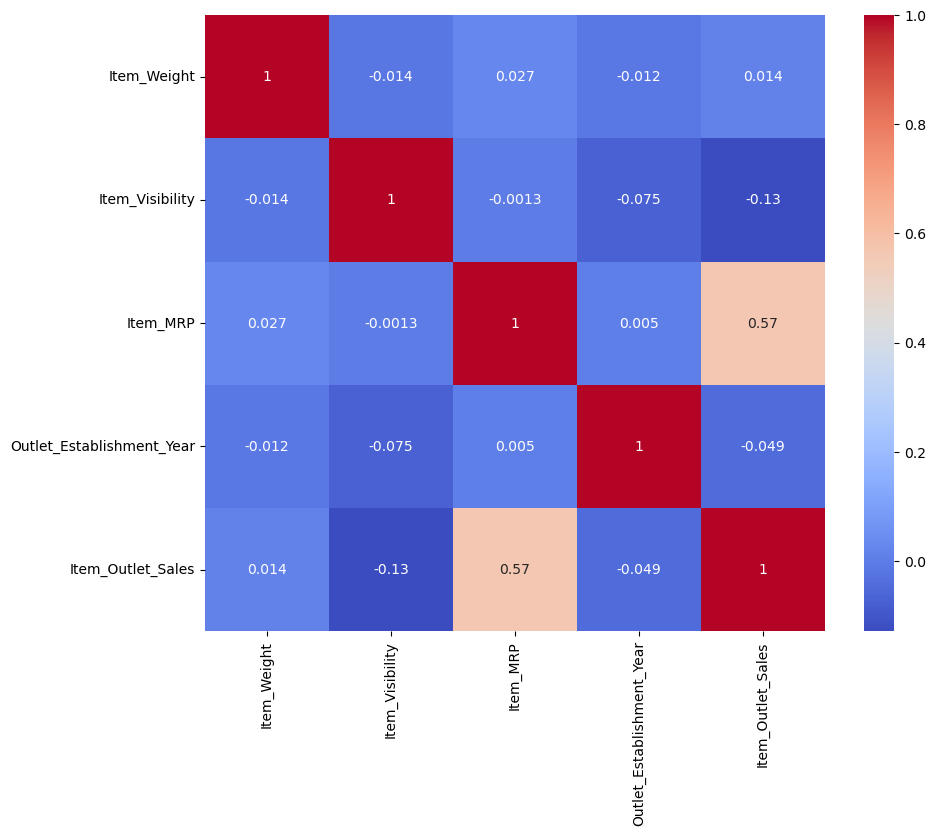

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [98]:
print(df['Item_Fat_Content'].unique())

['Low Fat' 'Regular' 'low fat' 'LF' 'reg']


# DATA CLEANING AND PREPROCESSING

### HANDLE MISSING DATA

In [99]:
# Fill Numerical Missing Values

df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [100]:
#Fill Categorical Missing Values

df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [101]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [102]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

In [103]:
print(df['Item_Fat_Content'].unique())

['Low Fat' 'Regular']


In [104]:
print((df['Item_Visibility'] == 0).sum())

526


In [105]:
# replace zero in Item_Visibility with NaN

import numpy as np

df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

In [106]:
#Fill using group mean
df['Item_Visibility'] = df.groupby('Item_Identifier')['Item_Visibility'].transform(
    lambda x: x.fillna(x.mean())
)

In [107]:
print(df['Item_Visibility'].isnull().sum())

0


### Detecting Outlier

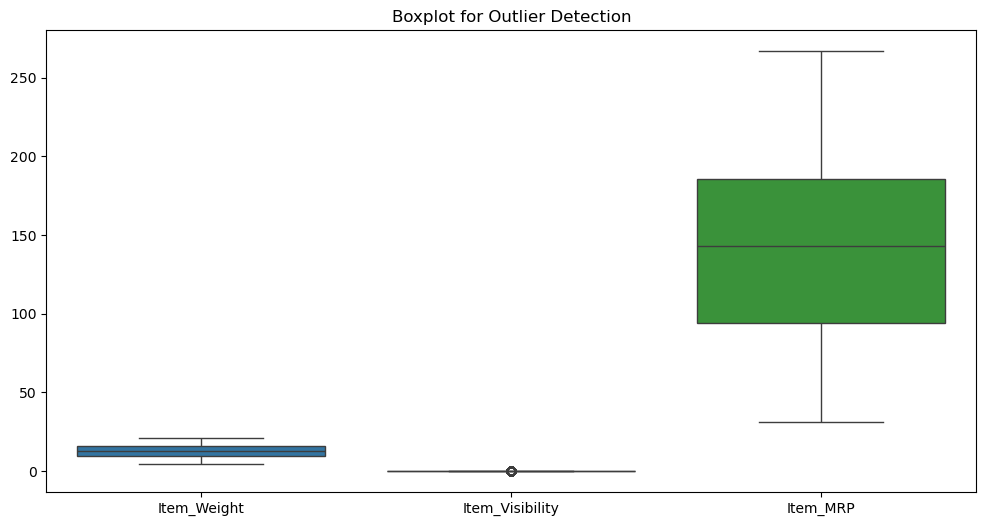

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Item_Weight', 'Item_Visibility', 'Item_MRP']])
plt.title("Boxplot for Outlier Detection")
plt.show()

### IQR Method

In [109]:
Q1 = df[['Item_Weight','Item_Visibility','Item_MRP']].quantile(0.25)
Q3 = df[['Item_Weight','Item_Visibility','Item_MRP']].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[['Item_Weight','Item_Visibility','Item_MRP']] < (Q1 - 1.5 * IQR)) |
            (df[['Item_Weight','Item_Visibility','Item_MRP']] > (Q3 + 1.5 * IQR)))

print(outliers.sum())

Item_Weight          0
Item_Visibility    144
Item_MRP             0
dtype: int64


In [110]:
Q1 = df['Item_Visibility'].quantile(0.25)
Q3 = df['Item_Visibility'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Item_Visibility'] = df['Item_Visibility'].clip(lower_bound, upper_bound)

In [111]:
# Recheck
Q1 = df['Item_Visibility'].quantile(0.25)
Q3 = df['Item_Visibility'].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df['Item_Visibility'] < (Q1 - 1.5 * IQR)) |
            (df['Item_Visibility'] > (Q3 + 1.5 * IQR)))

print(outliers.sum())

0


##### Outliers in the Item_Visibility feature were handled using the Interquartile Range (IQR) method. Extreme values were capped within acceptable bounds to reduce their influence on the model while preserving the dataset.

### Feature Engineering

In [112]:
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])

In [113]:
df['Item_Category'] = df['Item_Category'].map({
    'FD': 'Food',
    'NC': 'Non-Consumable',
    'DR': 'Drinks'
})

In [114]:
df.loc[df['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

In [115]:
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

### Encoding Categorical Variables

#### Label Encoding (for small categories)

In [116]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Item_Fat_Content'] = le.fit_transform(df['Item_Fat_Content'])
df['Outlet_Size'] = le.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type'] = le.fit_transform(df['Outlet_Location_Type'])
df['Item_Category'] = le.fit_transform(df['Item_Category'])

#### One-Hot Encoding (for larger categories)

In [117]:
df = pd.get_dummies(df, columns=[
    'Item_Type',
    'Outlet_Identifier',
    'Outlet_Type'
], drop_first=True)

In [118]:
df.drop('Item_Identifier', axis=1, inplace=True)

In [119]:
df

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Item_Category,Outlet_Age,...,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0,0.016047,249.8092,1999,1,0,3735.1380,1,27,...,False,False,False,False,False,False,True,True,False,False
1,5.920,2,0.019278,48.2692,2009,1,2,443.4228,0,17,...,True,False,False,False,False,False,False,False,True,False
2,17.500,0,0.016760,141.6180,1999,1,0,2097.2700,1,27,...,False,False,False,False,False,False,True,True,False,False
3,19.200,2,0.022911,182.0950,1998,1,2,732.3800,1,28,...,False,False,False,False,False,False,False,False,False,False
4,8.930,1,0.016164,53.8614,1987,0,2,994.7052,2,39,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0,0.056783,214.5218,1987,0,2,2778.3834,1,39,...,False,False,False,False,False,False,False,True,False,False
8519,8.380,2,0.046982,108.1570,2002,1,1,549.2850,1,24,...,False,False,False,False,True,False,False,True,False,False
8520,10.600,1,0.035186,85.1224,2004,2,1,1193.1136,2,22,...,False,False,False,True,False,False,False,True,False,False
8521,7.210,2,0.145221,103.1332,2009,1,2,1845.5976,1,17,...,True,False,False,False,False,False,False,False,True,False


### Feature Scaling

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

df[num_cols] = scaler.fit_transform(df[num_cols])

### Data Spliting 

In [121]:
from sklearn.model_selection import train_test_split

X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Linear Regression Model

In [122]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:
y_pred = model.predict(X_test)

### Model Evaluation

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 791.3043710086321
RMSE: 1068.9205358471245
R2 Score: 0.5796160060813401


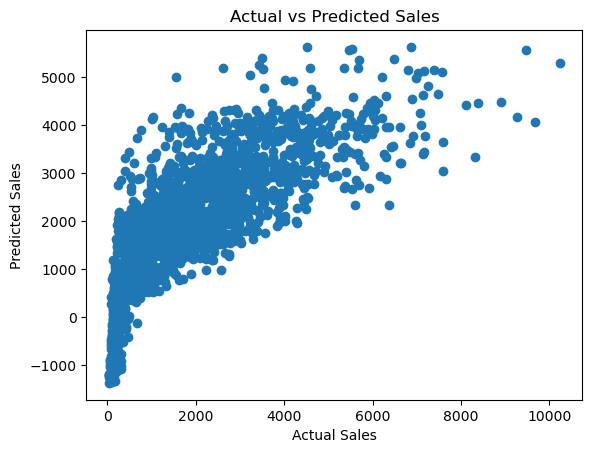

In [125]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

##### The linear regression model achieved moderate performance, indicating that while it is effective for capturing linear relationships, it may not fully represent complex patterns in sales data. Further improvements can be achieved using advanced models or feature transformations.

### Apply Log Transformation

In [127]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(rf, params, cv=3, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [128]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

from sklearn.metrics import r2_score
print("Tuned RF R2:", r2_score(y_test, y_pred_rf))

Tuned RF R2: 0.614109147683016


In [129]:
import joblib

joblib.dump(best_rf, 'sales_model.pkl')   # or use your preferred model
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [130]:
import joblib

joblib.dump(best_rf, 'model.pkl')
joblib.dump(X.columns, 'columns.pkl')

['columns.pkl']

In [131]:
import joblib

joblib.dump(model, 'lr_model.pkl')

['lr_model.pkl']

### Pipeline

In [134]:
df = pd.read_csv("Train.csv")

In [135]:
# Fix fat content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

# Handle missing
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)

# Fix visibility
df['Item_Visibility'] = df['Item_Visibility'].replace(0, df['Item_Visibility'].mean())

C:\Users\Facul\AppData\Local\Temp\ipykernel_19148\4194416758.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
C:\Users\Facul\AppData\Local\Temp\ipykernel_19148\4194416758.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [136]:
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

In [137]:
# Drop ID column (not useful)
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
import joblib

X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

cat_cols = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])

pipeline.fit(X, y)

joblib.dump(pipeline, 'sales_pipeline.pkl')

['sales_pipeline.pkl']